In [2]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.68.0-cp314-cp314-win_amd64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached packaging-26.3-py3-none-any.whl (129 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl (43.0 MB)
Using cached numba-0.68.0-cp314-cp314-win_amd64.whl (2.8 MB)

  Attempting uninstall: packaging

   ------ --------------------------------- 1/6 [packaging]
    Found existing installation: packaging 20.9
   ------ ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.3 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

In [4]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_shap)

print("SHAP calculation complete")

SHAP calculation complete


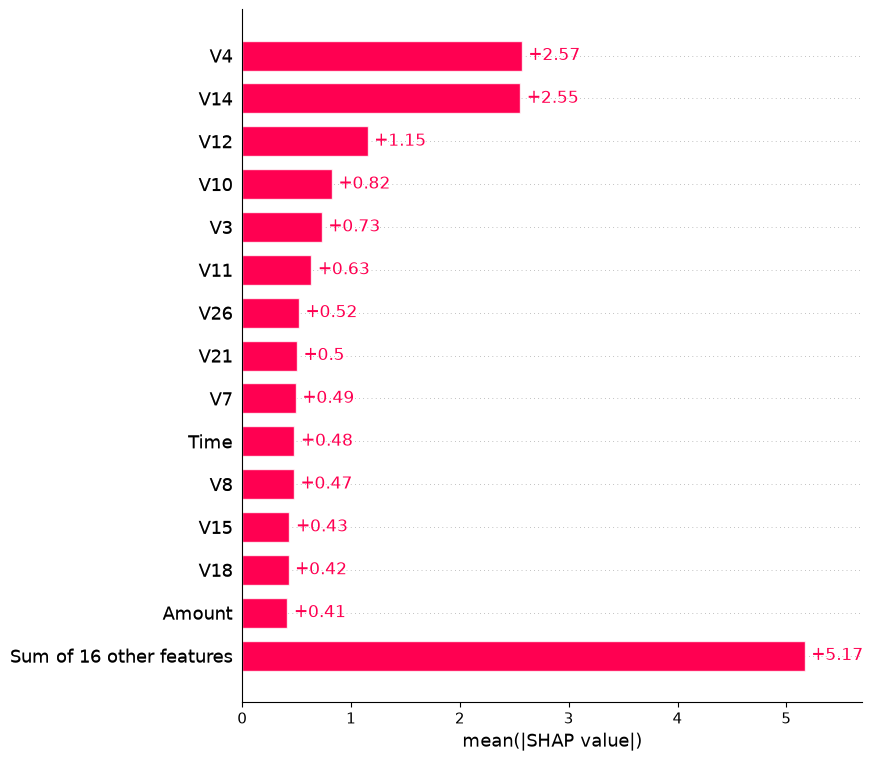

In [6]:
shap.plots.bar(
    shap_values,
    max_display=15
)

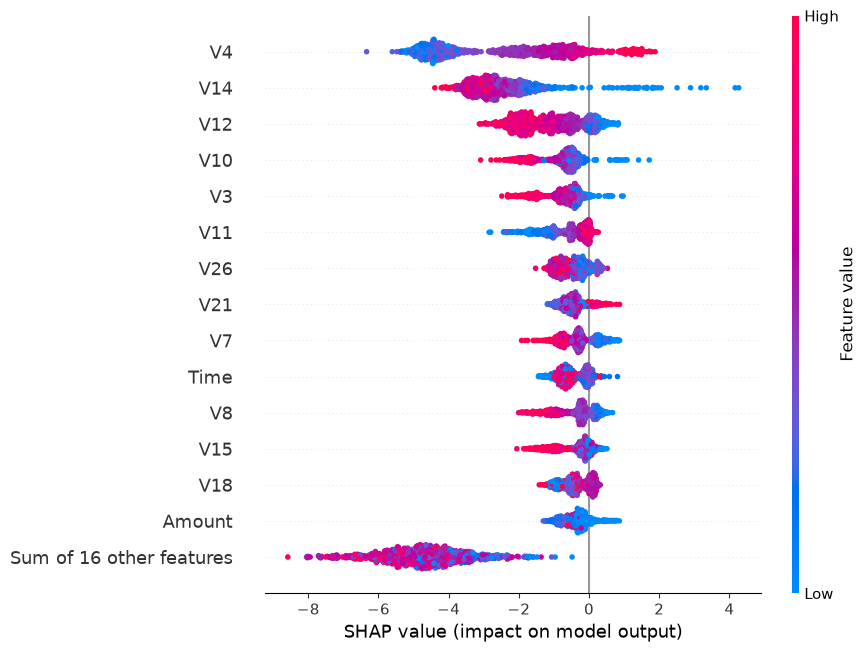

In [7]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [8]:
fraud_indices = X_test.index[y_test == 1]

sample_index = fraud_indices[0]

sample = X_test.loc[[sample_index]]

sample_shap = explainer(sample)

print("Actual class:", y_test.loc[sample_index])
print(
    "Predicted probability:",
    xgb_model.predict_proba(sample)[0][1]
)

Actual class: 1
Predicted probability: 0.9998702


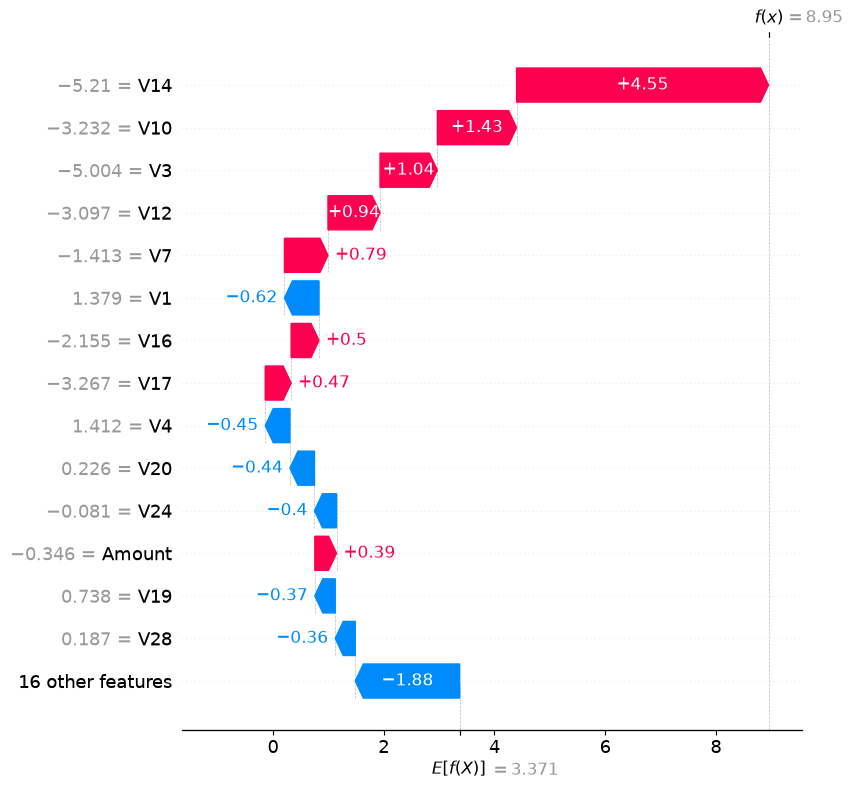

In [9]:
shap.plots.waterfall(
    sample_shap[0],
    max_display=15
)

In [10]:
sample = X_test.iloc[0]

sample.to_dict()

{'Time': 1.1303853637316712,
 'V1': -1.08860252327554,
 'V2': 0.227684493717604,
 'V3': 1.70446423633482,
 'V4': -2.35333183593795,
 'V5': -0.0205756088947456,
 'V6': -0.172106743175544,
 'V7': 0.583031671396642,
 'V8': 0.0617329021383216,
 'V9': 0.239968628337737,
 'V10': -1.31502430302492,
 'V11': 0.656777603828121,
 'V12': 0.764813769585199,
 'V13': 0.407951980688857,
 'V14': -0.156424317805708,
 'V15': -0.0674871993672851,
 'V16': 0.631197952122071,
 'V17': -1.08135240543906,
 'V18': 0.632738493297563,
 'V19': -0.121099129343154,
 'V20': -0.0738035734416213,
 'V21': 0.217620686602102,
 'V22': 0.653238021876026,
 'V23': -0.327775067273328,
 'V24': -0.315683709621901,
 'V25': 0.583261642757641,
 'V26': 0.743449612737544,
 'V27': -0.120431966266262,
 'V28': 0.0051651175831809,
 'Amount': -0.1121638061444127}

In [11]:
import json

raw_sample = df.drop(columns=["Class"]).loc[X_test.index].iloc[0]

print(json.dumps(raw_sample.to_dict(), indent=2))

{
  "Time": 148580.0,
  "V1": -1.08860252327554,
  "V2": 0.227684493717604,
  "V3": 1.70446423633482,
  "V4": -2.35333183593795,
  "V5": -0.0205756088947456,
  "V6": -0.172106743175544,
  "V7": 0.583031671396642,
  "V8": 0.0617329021383216,
  "V9": 0.239968628337737,
  "V10": -1.31502430302492,
  "V11": 0.656777603828121,
  "V12": 0.764813769585199,
  "V13": 0.407951980688857,
  "V14": -0.156424317805708,
  "V15": -0.0674871993672851,
  "V16": 0.631197952122071,
  "V17": -1.08135240543906,
  "V18": 0.632738493297563,
  "V19": -0.121099129343154,
  "V20": -0.0738035734416213,
  "V21": 0.217620686602102,
  "V22": 0.653238021876026,
  "V23": -0.327775067273328,
  "V24": -0.315683709621901,
  "V25": 0.583261642757641,
  "V26": 0.743449612737544,
  "V27": -0.120431966266262,
  "V28": 0.0051651175831809,
  "Amount": 60.0
}
